**U-net network for image segmentation** 

In [6]:
#!pip install imagecodecs
#!pip install --upgrade tifffile imagecodecs

In [7]:
import tensorflow as tf
import glob
import os
import numpy as np

**Encoder**

In [8]:
def encoder_block(inputs, num_filters):

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    p = tf.keras.layers.MaxPool2D((2,2))(x)

    return x, p  

**Decoder**

In [9]:
def decoder_block(inputs, skip_features, num_filters):

    x = tf.keras.layers.Conv2DTranspose(
        num_filters, (2, 2), strides=2, padding='same'
    )(inputs)

    x = tf.keras.layers.Concatenate()([x, skip_features])

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

**Defining the Unet model**

In [10]:
def unet_model(input_shape=(512, 512, 3), num_classes=1):

    inputs = tf.keras.layers.Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    #s4, p4 = encoder_block(p3, 512)

    # bottleneck
    b1 = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(p3)
    b1 = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(b1)

    #d1 = decoder_block(b1, s4, 512)
    d1 = decoder_block(b1, s3, 256)
    d2 = decoder_block(d1, s2, 128)
    d3 = decoder_block(d2, s1, 64)

    outputs = tf.keras.layers.Conv2D(num_classes, 1, activation='sigmoid')(d3)

    return tf.keras.Model(inputs, outputs)

if __name__ == '__main__':
    model = unet_model(input_shape=(512, 512, 3), num_classes=1)
    model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 512, 512,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 512, 512,  │          0 │ conv2d_8[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 512, 512,  │     36,928 │ activation_6[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 512, 512,  │          0 │ conv2d_9[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 256, 256,  │          0 │ activation_7[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 256, 256,  │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 256, 256,  │          0 │ conv2d_10[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 256, 256,  │    147,584 │ activation_8[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 256, 256,  │          0 │ conv2d_11[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 128, 128,  │    295,168 │ max_pooling2d_4[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 128, 128,  │          0 │ conv2d_12[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 128, 128,  │    590,080 │ activation_10[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 128, 128,  │          0 │ conv2d_13[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ activation_11[0]… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_5[

 Total params: 7,697,345 (29.36 MB)

 Trainable params: 7,697,345 (29.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def unet_model2(input_shape=(512, 512, 3), num_classes=1):

    inputs = tf.keras.layers.Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # bottleneck
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same', activation='relu')(p4)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same', activation='relu')(b1)

    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = tf.keras.layers.Conv2D(num_classes, 1, activation='sigmoid')(d4)

    return tf.keras.Model(inputs, outputs)

if __name__ == '__main__':
    model = unet_model2(input_shape=(512, 512, 3), num_classes=1)
    model.summary()

**data loading**

**Load paths**

In [12]:
import os
import glob

ROOT = "/kaggle/input/datasets/cedricniango"

IMAGE_DIR = os.path.join(ROOT, "dir-01-png")
MASK_DIR  = os.path.join(ROOT, "01-gt-seg-png")


def get_dataset_paths(image_dir, mask_dir):

    image_paths = sorted(glob.glob(os.path.join(image_dir, "t*.png")))

    mask_files = set(os.listdir(mask_dir))

    image_list = []
    mask_list = []

    for img_path in image_paths:

        name = os.path.basename(img_path)
        idx = ''.join(filter(str.isdigit, name))

        mask_name = f"man_seg{idx}.png"

        if mask_name in mask_files:
            image_list.append(img_path)
            mask_list.append(os.path.join(mask_dir, mask_name))

    print(f"Matched pairs: {len(image_list)}")

    return image_list, mask_list

**Image Preprocessing and mask** 

In [13]:
import imageio.v2 as imageio
#import tifffile as tiff
import tensorflow as tf
import numpy as np

IMG_SIZE = 512

def load_sample(img_path, mask_path):

    img = tf.io.read_file(img_path)
    img = tf.io.decode_png(img, channels=1)

    mask = tf.io.read_file(mask_path)
    mask = tf.io.decode_png(mask, channels=1)

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))

    img = tf.cast(img, tf.float32) / 255.0
    mask = tf.cast(mask > 0, tf.float32)

    return img, mask

**Data augmentation**

In [14]:
'''def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    return img, mask'''

def augment(img, mask):

    # horizontal flip 
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    # vertical flip 
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    # 90° Rotation 
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    mask = tf.image.rot90(mask, k)

    # Brightness (image only)
    img = tf.image.random_brightness(img, max_delta=0.1)

    # Contrast (image only)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)

    # 
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.02)
    img = img + noise

    # Clipping
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, mask

**Dataset creation**

In [15]:
def create_dataset(image_paths, mask_paths, batch_size=8, augment_data=True):

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))

    dataset = dataset.map(
        load_sample,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if augment_data:
        dataset = dataset.map(
            augment,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.shuffle(100)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

**Usage**

In [16]:
ROOT = "DIC-C2DH-HeLa"
IMAGE_DIR = "/kaggle/input/datasets/cedricniango/dir-01-png"
MASK_DIR = "/kaggle/input/datasets/cedricniango/01-gt-seg-png"

IMAGE_DIR_valid = "/kaggle/input/datasets/cedricniango/dir-02-png"
MASK_DIR_valid = "/kaggle/input/datasets/cedricniango/02-gt-seg-png"

train_img, train_mask = get_dataset_paths(IMAGE_DIR, MASK_DIR)
valid_img, valid_mask = get_dataset_paths(IMAGE_DIR_valid, MASK_DIR_valid)

train_dataset = create_dataset(train_img, train_mask, batch_size=4, augment_data=True)
valid_dataset  = create_dataset(valid_img, valid_mask, batch_size=4, augment_data=False)

Matched pairs: 9
Matched pairs: 9


**VERIFICATION**

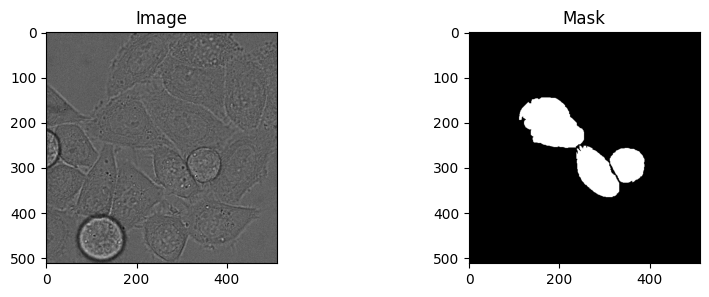

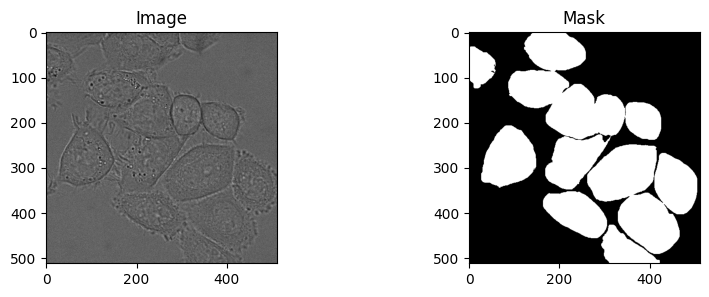

In [17]:
import matplotlib.pyplot as plt

def show_sample(ds):
    for img, mask in ds.take(2):
        plt.figure(figsize=(10,3))

        plt.subplot(1,2,1)
        plt.title("Image")
        plt.imshow(img[0,...,0], cmap='gray')

        plt.subplot(1,2,2)
        plt.title("Mask")
        plt.imshow(mask[0,...,0], cmap='gray')

        plt.show()

show_sample(train_dataset)

**TRAINING AND LOSS FUNCTION**

*Loss function*

In [18]:
# Loss BCE (Binary cross-entropy): https://softwaremill.com/instance-segmentation-loss-functions/
# Loss Dice : https://www.tensorflow.org/api_docs/python/tf/keras/losses/Dice
def dice_loss(y_true, y_pred, epsi=1e-7):
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    #epsi = 1e-7
    #dice loss = 1 - dice_score
    return 1 - (2 * tf.reduce_sum(y_true * y_pred)) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + epsi) #Intersection / Union


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * d_loss

**Compile model**

In [19]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [20]:
IMAGE_SIZE = 512
model = unet_model(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1), num_classes=1)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
             loss=bce_dice_loss,
             metrics=["accuracy"]
             )

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=50,              # nb of epochs without improvement
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor="val_loss",
    mode='min',
    save_best_only=True,
    verbose=1
)

In [21]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=200,
    #callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/200


I0000 00:00:1776983627.510454     106 service.cc:152] XLA service 0x120ae100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776983627.510501     106 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776983627.510507     106 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776983628.616557     106 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776983681.573803     106 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3/3 ━━━━━━━━━━━━━━━━━━━━ 108s 24s/step - accuracy: 0.4491 - loss: 0.6188 - val_accuracy: 0.5215 - val_loss: 0.5917
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 859ms/step - accuracy: 0.4032 - loss: 0.6249 - val_accuracy: 0.5234 - val_loss: 0.5915
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 850ms/step - accuracy: 0.4099 - loss: 0.6235 - val_accuracy: 0.5230 - val_loss: 0.5911
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 841ms/step - accuracy: 0.3984 - loss: 0.6272 - val_accuracy: 0.5212 - val_loss: 0.5901
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 819ms/step - accuracy: 0.4291 - loss: 0.6192 - val_accuracy: 0.5207 - val_loss: 0.5898
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 815ms/step - accuracy: 0.4148 - loss: 0.6214 - val_accuracy: 0.5227 - val_loss: 0.5901
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 813ms/step - accuracy: 0.4234 - loss: 0.6188 - val_accuracy: 0.5228 - val_loss: 0.5903
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 810ms/step - accuracy: 0.4400 - loss: 0.6170 - val_accuracy: 0.5252 - val_loss: 0.5

In [29]:
# Save model
model.save("unet_model_150..keras")

**Plot training curves**

In [30]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]

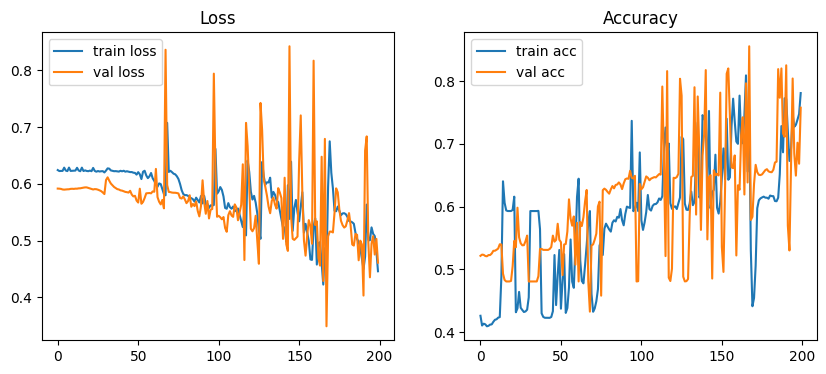

In [24]:
import matplotlib.pyplot as plt

def plot_training(history):

    plt.figure(figsize=(10,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.title("Loss")
    plt.legend()

    # Accuracy (si disponible)
    if "accuracy" in history.history:
        plt.subplot(1,2,2)
        plt.plot(history.history["accuracy"], label="train acc")
        plt.plot(history.history["val_accuracy"], label="val acc")
        plt.title("Accuracy")
        plt.legend()

    plt.show()

plot_training(history)

**Save curves**

In [25]:
import json

with open("history.json", "w") as f:
    json.dump(history.history, f)

**INFERENCE**

In [31]:
def load_test_image(path):

    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)

    img = tf.image.resize(img, (512, 512))
    img = tf.cast(img, tf.float32) / 255.0

    return img

def create_test_dataset(image_paths, batch_size=4):

    dataset = tf.data.Dataset.from_tensor_slices(image_paths)

    dataset = dataset.map(
        lambda x: load_test_image(x),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 999ms/step


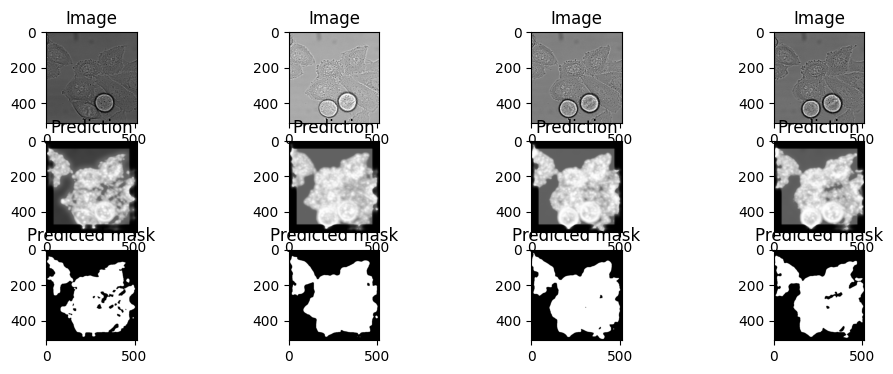

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step


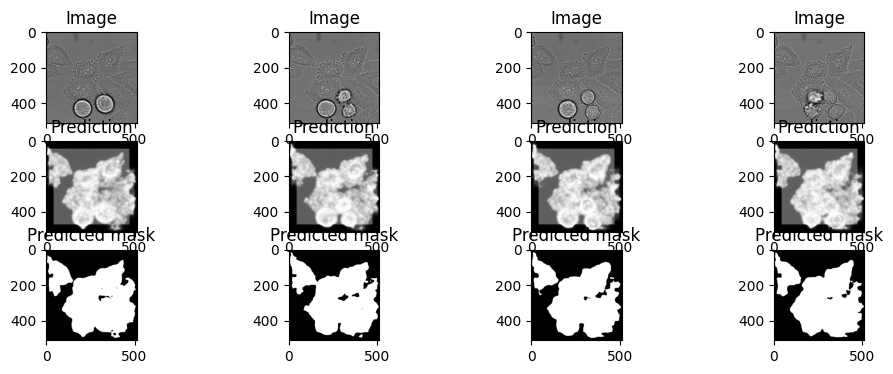

In [38]:
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import glob

#Load model
model = tf.keras.models.load_model(
                                  '/kaggle/working/unet_model_150.h5',
                                   compile=False)

# Test set
IMAGE_DIR_test = "/kaggle/input/datasets/cedricniango/dir-01-test-png"
test_img = sorted(glob.glob(os.path.join(IMAGE_DIR_test, '*.png')))
test_dataset = create_test_dataset(test_img, batch_size=4)

'''def show_predictions(model, dataset):

    for img, mask in dataset.take(1):

        pred = model.predict(img)

        plt.figure(figsize=(12,4))

        # Image
        plt.subplot(1,3,1)
        plt.title("Image")
        plt.imshow(img[0,...,0], cmap="gray")

        # Ground truth
        plt.subplot(1,3,2)
        plt.title("Mask GT")
        plt.imshow(mask[0,...,0], cmap="gray")

        # Prediction
        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred[0,...,0] > 0.5, cmap="gray")

        plt.show()

show_predictions(model, test_dataset)'''
#preds = model.predict(test_dataset)

def show_predictions(dataset, model):

    for imgs in dataset.take(2):

        preds = model.predict(imgs)

        plt.figure(figsize=(12,4))

        for i in range(4):

            plt.subplot(3,4,i+1)
            plt.imshow(imgs[i], cmap='gray')
            plt.title("Image")

            plt.subplot(3,4,i+5)
            plt.imshow(preds[i,...,0], cmap="gray")
            #print(f"MAX values of preds: {preds[i,...,0].max()}")
            #print(f"MIN values of preds: {preds[i,...,0].min()}")
            plt.title("Prediction")

            plt.subplot(3,4,i+9)
            plt.imshow(preds[i,...,0] > 0.5, cmap="gray")
            #print(f"MAX values of preds: {preds[i,...,0].max()}")
            #print(f"MIN values of preds: {preds[i,...,0].min()}")
            plt.title("Predicted mask")

        plt.show()
show_predictions(test_dataset, model)